# Demo de implementación de un tipo de algoritmo de Computación Evolutiva (CE) para resolver el Problema del Vendedor Viajero (o TSP) y encontrar el mejor camino para unir varios puntos
Utiliza la librería DEAP disponible en https://deap.readthedocs.io/en/master/

In [1]:
#@title Instalar librería DEAP
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 2.1 MB/s eta 0:00:00


In [2]:
#@title Cargar librerías
import random
import math
import numbers
import numpy as np
import matplotlib.pyplot as plt

from deap import creator
from deap import base
from deap import tools

import pickle
import codecs

import matplotlib
import matplotlib.pyplot as plt
import networkx
from IPython.display import display
from PIL import Image

import matplotlib as mpl
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import ipywidgets as widgets
from ipywidgets import Box, Layout, IntSlider
from ipywidgets import Layout
from IPython.display import clear_output

print("\nLibrerías importadas")


Librerías importadas


# Definición del Problema a Resolver:

In [3]:
#@title Configurar Posiciones Fijas / Manuales
posDefinidas = []
defPosicionesManual = True #@param {type:"boolean"}
#@markdown Nota: si no marca esta opción el grafo se genera en forma aleatoria.

if defPosicionesManual:
  # indicar las posiciones (x, y)
  # que corresponden
  # a cada uno de los puntos a unir
  posDefinidas.append( [1, 1])
  posDefinidas.append( [100, 1])
  posDefinidas.append( [1, 100])
  posDefinidas.append( [100, 100])
  posDefinidas.append( [50, 50])
  posDefinidas.append( [5, 50])
  posDefinidas.append( [50, 5])



Clase Mapa de Búqueda definida TSP

Mapa de búsqueda TSP definido

## Posiciones generadas:  7
   A --> [1, 1]
   B --> [100, 1]
   C --> [1, 100]
   D --> [100, 100]
   E --> [50, 50]
   F --> [5, 50]
   G --> [50, 5]


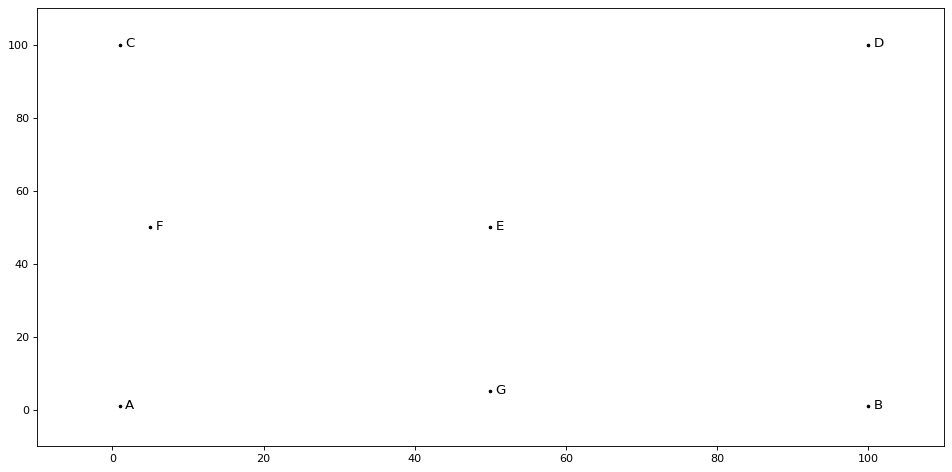


## Matriz de Distancias: 
         A        B        C        D       E        F        G
A    0.000   99.000   99.000  140.007  69.296   49.163   49.163
B   99.000    0.000  140.007   99.000  70.007  106.892   50.160
C   99.000  140.007    0.000   99.000  70.007   50.160  106.892
D  140.007   99.000   99.000    0.000  70.711  107.355  107.355
E   69.296   70.007   70.007   70.711   0.000   45.000   45.000
F   49.163  106.892   50.160  107.355  45.000    0.000   63.640
G   49.163   50.160  106.892  107.355  45.000   63.640    0.000

 - Distancia promedio:  83.0  --> Total promedio:  579.0




In [4]:
# @title Especificar clase MAPA DE BÚSQUEDA TSP {"single-column":true}

import copy
from scipy import spatial
import pandas as pd

#@markdown Parámetros para TSP:
CANT_POSICIONES = 10 #@param {type:"slider", min:3, max:25, step:1}
if CANT_POSICIONES < 3:
  CANT_POSICIONES = 3

MIN_ESPACIO_BUSQ = 0 #@param {type:"slider", min:-100, max:0, step:5}
MAX_ESPACIO_BUSQ = 100  #@param {type:"slider", min:0, max:100, step:5}

# clase para TSP
class MapaBusquedaTSP(object):

    def __init__(self, limMin=-100, limMax=100, posiciones=[], cantPosiciones=10):
          self.limMin = limMin
          self.limMax = limMax
          if (posiciones is None) or (len(posiciones) < 2):
            # genera posiciones al azar
            if cantPosiciones > 2:
              self.cantidadPosiciones = cantPosiciones
            else:
              self.cantidadPosiciones = 2
            self.generarPosicionesRnd( self.cantidadPosiciones)
          else:
            # usa las posiciones indicadas
            self.posiciones = copy.deepcopy(posiciones)
            self.cantidadPosiciones = len(self.posiciones)
          # calcula la matriz de distancia
          self.matrizDistancia = spatial.distance.cdist(self.posiciones, self.posiciones, metric='euclidean')
          self.maxDistanciaPenalizar = np.max(  self.matrizDistancia ) + 1

    def generarPosicionesRnd(self, cantPosiciones):
        # Define las posiciones al azar
        self.posiciones = []
        for i in range(cantPosiciones):
          auxPos = [ random.randint(self.limMin, self.limMax),  random.randint(self.limMin, self.limMax) ]
          self.posiciones.append( auxPos )
        return True

    def formateaIdPosicion(self, idPos):
        return chr(idPos+65)

    def formateaListaPosiciones(self, posList):
      auxRes = "[ "
      for id in posList:
        auxRes = auxRes + self.formateaIdPosicion(id) + " - "
      auxRes = auxRes[:len(auxRes)-2] + "]"
      return auxRes

    def mostrarMatriz(self, matriz, titulo=""):
        print("\n"+titulo)
        cmd = pd.DataFrame(
            np.round(matriz, decimals=3),
            index=["  "+self.formateaIdPosicion(x) for x in range(self.cantidadPosiciones)],
            columns=[self.formateaIdPosicion(x) for x in range(self.cantidadPosiciones)]
          )
        # agrega para poder mostrar la matrix completa
        pd.options.display.max_rows = 100
        pd.options.display.max_columns = 100
        print(cmd)
        return

    def printInformacion(self):
        # Muestra la información sobre el Mapa de Búsqueda

        ## muesta las posiciones generadas
        print("\n## Posiciones generadas: ", self.cantidadPosiciones)
        i = 0
        for auxPos in self.posiciones:
            print("  ", self.formateaIdPosicion(i),"-->", auxPos)
            i = i + 1
        # muestra gráfico con
        self.graficar(True)

        # muestra la matriz de distancia
        self.mostrarMatriz(self.matrizDistancia, "## Matriz de Distancias: ")
        # calcula distancia promedio
        filter_arr = self.matrizDistancia > 0
        distAvg = np.mean( self.matrizDistancia[filter_arr] )
        print("\n - Distancia promedio: ", round(distAvg, 0), " --> Total promedio: ", round(distAvg*self.cantidadPosiciones, 0))
        print("\n")
        return

    # Definir posiciones de un recorrido
    def devPosicionesRecorrido(self, recorrido, agregaPrimeroFinal=True):
      # determina el recorrido
      coordX = []
      coordY = []
      for r in recorrido:
        pos = self.posiciones[r]
        coordX.append( pos[0] )
        coordY.append( pos[1] )
      if agregaPrimeroFinal:
        # agrega al final la posición original para que cierre el circuito
        pos = self.posiciones[ recorrido[0] ]
        coordX.append( pos[0] )
        coordY.append( pos[1] )
      return coordX, coordY


    def graficar(self, mostrar=True, ax=None):
      if ax is None:
        fig = plt.figure(figsize=(12,6), dpi=80)
        ax = fig.add_subplot(111)
      else:
        fig = ax.figure
      ax.axis([self.limMin-10, self.limMax+10, self.limMin-10, self.limMax+10])
      # muesta posiciones en el gráfico
      i = 0
      for auxPos in self.posiciones:
          ax.scatter(auxPos[0], auxPos[1], color="black", s=5)
          ax.annotate(self.formateaIdPosicion(i), (auxPos[0]+0.7, auxPos[1]-0.7), fontsize=12)
          i = i + 1
      if mostrar:
        plt.tight_layout()
        plt.show()
      return fig, ax

    def calculaDistanciaTotal(self, routine):
        num_points = len(routine)
        return sum([self.matrizDistancia[routine[i % num_points], routine[(i + 1) % num_points]] for i in range(num_points)])

print("\nClase Mapa de Búqueda definida TSP")

# Define el Mapa de Búsqueda
mapa = MapaBusquedaTSP(limMin=MIN_ESPACIO_BUSQ, limMax=MAX_ESPACIO_BUSQ, \
                    posiciones=posDefinidas,
                    cantPosiciones=CANT_POSICIONES)

print("\nMapa de búsqueda TSP definido")

# Muestra su información
mapa.printInformacion()


# Preparación del Algoritmo:

In [5]:
#@title Definir FUNCIÓN DE APTITUD Y ESTRUCTURA DEL CROMOSOMA

#@markdown > Función de Aptitud:
#@markdown - indica que es para minimizar.
#@markdown - determina la aptitud como la suma de las distancias a ser recorridas para unir todos los puntos.
#@markdown   Pero, también penaliza si quedan puntos repetidos y/o puntos por los que no pasa.

## Inicializa objeto Toolbox auxiliar
toolbox = base.Toolbox()

# indica que es la función de aptitud es para maximizar
creator.create("Fitness", base.Fitness, weights=(-1.0,))
esProblemaMaximizar = False

# definimos la función de aptitud
def funcAptitud(individual):
    # calcula la distancia total del recorrido
    res = mapa.calculaDistanciaTotal(individual)
    # penaliza si hay puntos por los que no pasa
    # y/o si hay puntos pasa más de una vez
    for i in range(mapa.cantidadPosiciones):
      cantI = individual.count(i) - 1
      if cantI < 0:
        # penaliza por falta punto
        res = res + mapa.maxDistanciaPenalizar
      elif cantI > 0:
        # penaliza por cada ocurrencia repetida
        res = res + mapa.maxDistanciaPenalizar * cantI
    return res,

# registra la función que se va a evaluar
toolbox.register("evaluate", funcAptitud)

print("\nFunción de Aptitud definida")


#@markdown > Estructura del Cromosoma:
#@markdown - indica que es una lista de valores enteros que indican los IDs de los puntos a ser recorridos.
inicializar_individuos = 'Espacial-Lista' #@param ["Azar", "Espacial-Lista"]

valorMax_genesCromosomas = mapa.cantidadPosiciones - 1
cant_genesCromosoma = mapa.cantidadPosiciones

# indica que los individuos son una lista de genes que aplica la función antes definida
creator.create("Individual", list, fitness=creator.Fitness)

# indica que los genes son enteros
if inicializar_individuos == 'Azar':
  # registra el tipo de individuo como lista valores al azar (puede haver repetidos y faltantes)
  toolbox.register("puntos", random.randint, 0, valorMax_genesCromosomas)
  toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.puntos, cant_genesCromosoma)
else:
  # registra el tipo de individuo como una permutación de posibles puntos
  # (así siempre tiende a generar combinaciones válidas, sin repetidos ni faltantes)
  toolbox.register("puntos", random.sample, range(mapa.cantidadPosiciones), mapa.cantidadPosiciones)
  toolbox.register("individual", tools.initIterate, creator.Individual,toolbox.puntos)

# registra la población a usar
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


print("\nCromosoma definido")


Función de Aptitud definida

Cromosoma definido


In [6]:
# @title Configurar OPERADORES GENÉTICOS {"single-column":true}
#@markdown definidos  en https://deap.readthedocs.io/en/master/api/tools.html#operators

#@markdown - Operador de SELECCIÓN:
tipo_seleccion = 'Ruleta' #@param ["Azar", "Torneo", "Ranking", "Ruleta", "Control s/nro Esperado"]

#@markdown - Operador de CRUZAMIENTO:
tipo_cruzamiento = 'Especial-Lista' #@param ["Simple-1Punto", "Simple-2Puntos", "Azar", "Especial-Lista"]
probab_cruzamiento = 75 #@param {type:"slider", min:0, max:100, step:1}
probab_cruzamiento = probab_cruzamiento/100.0

#@markdown - Operador de MUTACIÓN:
tipo_mutacion = 'Adaptativo por Convergencia' #@param ["Simple", "Temperatura Ascendente", "Temperatura Descendente", "Adaptativo por Convergencia"]
probab_mutacion = 30 #@param {type:"slider", min:0, max:100, step:1}
probab_mutacion = probab_mutacion/100.0

#@markdown - Operador de ACTUALIZAR POBLACIÓN:
tipo_actualizar_poblacion = 'Ranking' #@param ["Torneo", "Ranking", "Ruleta", "Control s/nro Esperado"]

#@markdown nota: el uso de los operadores dependerá del Tipo de Algoritmo seleccionado...

from operator import attrgetter

# implementa control sobre nro esperado
def selControlNroEsperado(individuals, k, fit_attr="fitness"):
    # individos seleccionados
    chosen = []
    # reordena para que queden mejores primero
    s_inds = sorted(individuals, key=attrgetter(fit_attr), reverse=True)
    # calcula promedio de aptitud general
    avg_fits = np.average([getattr(ind, fit_attr).values[0] for ind in individuals])
    # preselecciona en base a la parte entera de los individuos
    indsHeurs = []
    sum_fits = 0.0
    for ind in s_inds:
      # calcula heurística y divide por promedio general
      h = getattr(ind, fit_attr).values[0] / avg_fits
      # toma parte entera
      h_entero = math.trunc(h)
      if h_entero > 0:
        # preselecciona el individuo
        # la cantidad de veces correspondiente
        for _ in range(h_entero):
          chosen.append( ind )
      # toma parte decimal como nueva heuristica
      h_decimal = h - h_entero
      indsHeurs.append( h_decimal )
      if h_decimal == 0.0:
        sum_fits += 0.00001
      else:
        sum_fits += h_decimal
    # controla cantidad de preseleccionados
    cantPreSel = len(chosen)
    if cantPreSel>=k:
      # si ya se alcanzo la cantidad, la devuelve
      return chosen[:k]
    # aplica ruleta para seleccionar el resto
    # -- código adaptado de selRoulette para DEAP --
    s_inds = sorted(individuals, key=lambda x: indsHeurs[individuals.index(x)], reverse=True)
    for i in range(k-cantPreSel):
        u = random.random() * sum_fits
        sum_ = 0
        for ind in s_inds:
            sum_ += getattr(ind, fit_attr).values[0]
            if sum_ > u:
                chosen.append(ind)
                break
    # deveulve seleccionados final
    if cantPreSel>k:
      return chosen[:k]
    else:
      return chosen

# Registrar tipo de Selección a aplicar con sus parámetros
if tipo_seleccion == 'Torneo':
  toolbox.register("select", tools.selTournament, tournsize=2)
elif tipo_seleccion == 'Ranking':
  toolbox.register("select", tools.selBest)
elif tipo_seleccion == 'Ruleta':
  toolbox.register("select", tools.selRoulette)
elif tipo_seleccion == 'Control s/nro Esperado':
  toolbox.register("select", selControlNroEsperado)
else:
  toolbox.register("select", tools.selRandom)

# Registrar tipo de Cruzamiento a aplicar con sus parámetros
if tipo_cruzamiento == 'Simple-1Punto':
  toolbox.register("mate", tools.cxOnePoint)
elif tipo_cruzamiento == 'Simple-2Puntos':
  toolbox.register("mate",  tools.cxTwoPoint)
elif tipo_cruzamiento == "Azar":
  toolbox.register("mate", tools.cxUniform, indpb=1.0/cant_genesCromosoma)
else:
  # como es una lista de puntos ya conocida, usa otro método de cruzamiento
  toolbox.register("mate", tools.cxOrdered)

# determmina tipo de mutación
if tipo_mutacion.lower() == 'simple':
  # probabilidad de mutación constante
  probabMutacion_base = abs(probab_mutacion)
  probabMutacion_dif = 0.0
elif "temperatura" in tipo_mutacion.lower():
  probab_mutacion = min(max(probab_mutacion, 0.01), 0.99)
  # probabilidad varía por ciclo usando valor constante
  if "descendente" in tipo_mutacion.lower():
    probabMutacion_base = 1.0
    probabMutacion_dif = -abs(probab_mutacion)
  else:
    probabMutacion_base = 0.0
    probabMutacion_dif = abs(probab_mutacion)
else:
  # probabilidad varía por ciclo usando desvío
  probabMutacion_base = abs(probab_mutacion)
  probabMutacion_dif = None

# Registrar tipo de Mutación a aplicar con sus parámetros
# (no importa tipo de mutación porque lo aplica después)
toolbox.register("mutate", tools.mutShuffleIndexes,  indpb=1.0/cant_genesCromosoma)

# Registrar tipo de Selección para actualizar población
if tipo_actualizar_poblacion == 'Torneo':
  toolbox.register("update_pop", tools.selTournament, tournsize=2)
elif tipo_actualizar_poblacion == 'Ruleta':
  toolbox.register("update_pop", tools.selRoulette)
elif tipo_actualizar_poblacion == 'Control s/nro Esperado':
  toolbox.register("update_pop", selControlNroEsperado)
else:
  toolbox.register("update_pop", tools.selBest)

print("\nOperadores Genéticos definidos")


Operadores Genéticos definidos


In [7]:
#@title Seleccionar Tipo de Algoritmo
#@markdown se define la clase auxiliar DEAP-WRAPPER para unficiar el proceso de los tipos de algoritmos.

# tipos de algoritmos soportados:
# - Algortimo Genético (AG)
# - Algoritmo de Computación Evolutiva genérico (CE)
# - Estrategia Evolucionaria (ES)
# - Programación Evolucionaria (PE)
# nota: en ES y PE el comportamiento es el mismo, depende tipos operadores elegidos
DEAP_Wrapper_tipos_algoritmos_soportados = ["AG", "CE", "ES", "PE"]

# clase auxiliar para facilitar implementar un algoritmo con la librería DEAP
# nota: se considera que la definición la función de aptitud, estructrura del cromosoma,
#       y los tipos de operador genético ya se hizo en toolbox
class DEAP_Wrapper(object):

  def __init__(self, toolbox, tipoAlgoritmo=DEAP_Wrapper_tipos_algoritmos_soportados[0],
               esProblemaMaximizar=True, funcFormatearIndividuo=None):
    ## Inicializa parámetros del algoritmo
    self._toolbox = toolbox
    self._esMejorMax = esProblemaMaximizar
    # determina función para formatear cromosoma de individuos
    if funcFormatearIndividuo is None:
      self._funcFormatearIndividuo = str
    else:
      self._funcFormatearIndividuo = funcFormatearIndividuo
    # determina tipo de algoritmo a usar
    tipoAlgoritmo = tipoAlgoritmo.strip().upper()
    assert (tipoAlgoritmo in DEAP_Wrapper_tipos_algoritmos_soportados), "Tipo de Algortimo " + str(tipoAlgoritmo)+ " no soportado!!!"
    self._tipoAlgoritmo = tipoAlgoritmo
    return

  # inicializa parámetros para las corridas
  # nota: los tipos de operadores se configuran directo en toolbox antes
  def configurarCorrida(self, cantIndividuos=None, probabCruzamiento=None,
                        probabMutacion_base=None, probabMutacion_dif=None):
    # configura cantidad de individuos de la corrida
    if cantIndividuos is None:
      self._cantIndividuos = 2
    else:
      self._cantIndividuos = max(cantIndividuos, 2)
    # configura probabilidad de cruzamiento
    if probabCruzamiento is None:
      self._probabCruzamiento = None
    elif self._tipoAlgoritmo != "CE":
      print("Warning: el tipo de algoritmo " + self._tipoAlgoritmo + " no soporta probabilidad de cruzamiento, se descarta!")
      self._probabCruzamiento = None
    else:
      self._probabCruzamiento = max(min(probabCruzamiento, 1.0), 0.0)
    # configura probabilidad de mutación
    if probabMutacion_base is None:
      self._probabMutacion_base = None
    else:
      self._probabMutacion_base = max(min(probabMutacion_base, 1.0), 0.0)
    if probabMutacion_dif is None:
      self._probabMutacion_dif = None
    else:
      self._probabMutacion_dif = max(min(probabMutacion_dif, 1.0), 0.0)
    return

  # función auxiliar para formatear el valor de aptitud de un individuo
  @staticmethod
  def fmtAptitud(valorApt):
    if valorApt is None:
      # no definido
      return None
    elif isinstance(valorApt, numbers.Number):
      # es directamente el valor de aptitud
      valorMostar = valorApt
    else:
      # asume que es un individuo
      valorMostar = valorApt.fitness.values[0]
    # devuelve redondeado
    return round(valorMostar, 3)

  # función auxiliar para mostrar indivudo con aptitud
  def renderIndividuo(self, individuo, valorAptitud=None):
    if valorAptitud is None:
      return self._funcFormatearIndividuo(individuo)
    else:
      return self._funcFormatearIndividuo(individuo) + " { " + str(valorAptitud) + " }"

  # función auxiliar para mostrar detalle población
  def mostrarPoblaDetalle(self, indivPobla, titulo=""):
    if titulo != "":
      print(titulo)
    for ind in indivPobla:
      print("\t " + self.renderIndividuo(ind, self.fmtAptitud(ind)))

  # función auxiliar para asigna el valor de aptitud a los individuos
  def _asignarAptitud(self, indivPobla):
      fitnesses = list(map(self._toolbox.evaluate, indivPobla))
      for ind, fit in zip(indivPobla, fitnesses):
          ind.fitness.values = fit

  # ejecuta generar población inicial
  def generarPoblacionInicial(self):
    # genera individuos
    indivPobla = self._toolbox.population(n=self._cantIndividuos)
    # Asigna el valor de aptitud a los individuos de la población inicial
    self._asignarAptitud(indivPobla)
    return indivPobla

  # ejecuta operador de Selección registrado
  # devolviendo los individuos seleccionados
  def hacerSeleccion(self, poblActual, cant_ind_selecc=None):
      # si no se indica cantidad
      if (cant_ind_selecc is None) or (cant_ind_selecc<=0):
        # cálcula cantidad de individuos a ser seleccionados  como la mitad + 1
        cant_ind_selecc = (len(poblActual)//2)+1
      # hace selección
      indivSelcc = self._toolbox.select(poblActual, cant_ind_selecc)
      # devuelve selecciones
      return indivSelcc

  # ejecuta operador Cruzamiento para un par de padres
  # devolviendo los hijos generados (deben recalcular aptitud)
  def hacerCruzamiento(self, padre1, padre2):
      # clona para no modificar padres
      hijo1 = self._toolbox.clone(padre1)
      hijo2 = self._toolbox.clone(padre2)
      # hace cruza
      self._toolbox.mate(hijo1, hijo2)
      # invalida aptitud (debe recalcular)
      del hijo1.fitness.values
      del hijo2.fitness.values
      # devuelve
      return hijo1, hijo2

  # ajusta probabilidad de mutación en base al tipo seleccionado
  def _ajustarProbabMutacion(self, mostrarDetalle=False):
      # si no tiene definda la probabilidad actual, lo deja igual
      if (self._probabMutacion_valor is None):
          return None
      # guarda valor anterior
      probab_mutacion_ant = self._probabMutacion_valor
      # analiza cómo corresponde modificar probabilidad de mutación
      if (self._probabMutacion_dif is None):
          if (self._ult_desvio_pobl is None):
            # si no hay desvio, asume probabilidad 50%
            probab_mutacion_new = 0.5
          else:
            # modifica considerando desvio
            # busca que a mayor desvío la probabilidad baje, y vicerversa
            probab_mutacion_new = math.exp(-abs(self._ult_desvio_pobl))
      else:
          # analiza valor de diferencia
          if (self._probabMutacion_dif == 0.0):
              # no modifica, constante
              return self._probabMutacion_valor
          else:
              # modifica usando diferencia
              probab_mutacion_new = self._probabMutacion_valor + self._probabMutacion_dif
      # controla mínimo y máximo
      self._probabMutacion_valor =  min(max(probab_mutacion_new, 0.0), 1.0)
      if mostrarDetalle and (probab_mutacion_ant!=self._probabMutacion_valor):
          # muestra nueva probabilidad si cambia
          print("\t - nueva probabilidad de mutación: " + str(round(self._probabMutacion_valor*100,2)) + "% ")
      # devuelve nuevo valor
      return self._probabMutacion_valor

  # ejecuta operador Mutación para un individuo
  # devolviendo el mutado (debe recalcular aptitud)
  def hacerMutacion(self, ind, mantenerOriginal=True):
      if mantenerOriginal:
        # clona para no modificar original
        mutant = self._toolbox.clone(ind)
      else:
        mutant = ind
      # hace mutación
      self._toolbox.mutate(mutant)
      # invalida aptitud (debe recalcular)
      del mutant.fitness.values
      # devuelve
      return mutant

  # ejecuta operador de Selección registrado
  # devolviendo los individuos seleccionados
  def hacerActualizacionPobla(self, poblActual, poblSeleccHijosMutados=None):
      # junta todas las poblaciones recibiidas
      if poblActual is None:
        poblActual = []
      if poblSeleccHijosMutados is not None:
        poblActual.extend( poblSeleccHijosMutados )
      # filtra tomando algunos para la siguiente generación
      # y los devuelve
      return self._toolbox.update_pop(poblActual, self._cantIndividuos)
      # devuelve selecciones


  # realiza la ejecución de un ciclo para un algoritmo AG
  def ejecutarCicloEsp_AG(self, poblActual=None, mostrarDetalle=False):
      # determina cantidad de población actual
      cantIndivActual = len(poblActual)
      # realiza la Selección
      indivSelecc = self.hacerSeleccion(poblActual=poblActual)
      if mostrarDetalle:
        self.mostrarPoblaDetalle(indivSelecc, "\n  (a) Individuos Seleccionados:")
      # realiza el Cruzamiento (solo de seleccionados)
      # generando cantidad de hijos igual a población actual
      if mostrarDetalle:
        print("\n  (b) Genera hijos por Cruzamiento: ")
      indivHijos = []
      # mientras todavía falte generar hijos
      while len(indivHijos) < cantIndivActual:
        # elige padres al azar
        # (puede ser que se tome dos veces al mismo)
        padre1 = random.choice(indivSelecc)
        padre2 = random.choice(indivSelecc)
        # hace cruzamiento
        hijo1, hijo2 = self.hacerCruzamiento(padre1, padre2)
        # agrega 1er hijo y muestra (parcial)
        indivHijos.append(hijo1)
        if mostrarDetalle:
            print("\t" + self._funcFormatearIndividuo(padre1) + " x " + self._funcFormatearIndividuo(padre2) + " = " + self._funcFormatearIndividuo(hijo1), end=" ")
        # si faltan más hijos
        if len(indivHijos) < cantIndivActual:
          # agrega 2do hijo y muestra
          indivHijos.append(hijo2)
          if mostrarDetalle:
            print(" & " + self._funcFormatearIndividuo(hijo2))
        else:
          # no agrega, pero hace salto de línea
          if mostrarDetalle:
            print("")
      # analiza si tiene que ajustar probabilidad de mutación
      if mostrarDetalle:
        print("\n  (c) Modifica Hijos por Mutación: ")
      self._ajustarProbabMutacion(mostrarDetalle)
      # realiza mutación
      indivMutados = []
      if random.random() < self._probabMutacion_valor:
        # ejecuta mutación:
        # selecciona al azar el individuo a mutar
        mutant = random.choice(indivHijos)
        # y lo muta aplicando el método
        if mostrarDetalle:
          print("\t se ejecuta: " + self._funcFormatearIndividuo(mutant), end=" ")
        # hace la mutación (modifica origianl)
        mutant = self.hacerMutacion(mutant, mantenerOriginal=False)
        del mutant.fitness.values
        if mostrarDetalle:
          print("--> " + self._funcFormatearIndividuo(mutant) +  "\n")
      elif mostrarDetalle:
        # no se ejecuta mutación
        print("\t no se ejecuta.")
      # asigna aptitud a los hijos
      self._asignarAptitud( indivHijos )
      # considera hijos directamente como siguiente generación
      poblaNew = indivHijos
      if mostrarDetalle:
        self.mostrarPoblaDetalle(poblaNew, "\n  (*) Siguiente Generación:")
        print("")
      assert len(indivHijos)==cantIndivActual, "La siguiente generación tiene diferente cantidad de individuos!!!"
      # devuelve población generada
      return poblaNew

  # realiza la ejecución de un ciclo para un algoritmo CE
  def ejecutarCicloEsp_CE(self, poblActual=None, mostrarDetalle=False):
      # realiza la Selección
      indivSelecc = self.hacerSeleccion(poblActual=poblActual)
      if mostrarDetalle:
        self.mostrarPoblaDetalle(indivSelecc, "\n  (a) Individuos Seleccionados:")
      # realiza el Cruzamiento (solo de seleccionados)
      # procesando todos los seleccionados
      if mostrarDetalle:
        print("\n  (b) Genera hijos por Cruzamiento: ")
      indivHijos = []
      for padre1 in indivSelecc:
        # analiza si hace cruzamiento
        if (self._probabCruzamiento is None) or \
            (self._probabCruzamiento >= 1.0) or \
            (random.random() < self._probabCruzamiento):
                # elige otro padre al azar
                # (puede ser que se tome dos veces al mismo)
                padre2 = random.choice(indivSelecc)
                # hace cruzamiento
                hijo1, hijo2 = self.hacerCruzamiento(padre1, padre2)
                # guarda los hijos obtenidos
                indivHijos.append(hijo1)
                indivHijos.append(hijo2)
                if mostrarDetalle:
                  print("\t" + self._funcFormatearIndividuo(padre1) + " x " + self._funcFormatearIndividuo(padre2) + " = " + self._funcFormatearIndividuo(hijo1) + " & " + self._funcFormatearIndividuo(hijo2))
      if len(indivHijos)>0:
        # asigna aptitud a los hijos
        self._asignarAptitud( indivHijos )
        # agrega en lista de seleccionados a los hijos
        indivSelecc.extend( indivHijos )
      elif mostrarDetalle:
        print("\t no se ejecuta.")
      # analiza si tiene que ajustar probabilidad de mutación
      if mostrarDetalle:
        print("\n  (c) Genera nuevos por Mutación: ")
      self._ajustarProbabMutacion(mostrarDetalle)
      # realiza mutación
      indivMutados = []
      for indiv in indivSelecc:
        # analiza si hace mutación
        if (self._probabMutacion_valor is None) or \
            (self._probabMutacion_valor >= 1.0) or \
            (random.random() < self._probabMutacion_valor):
                # muta y lo guarda
                mutant = self.hacerMutacion(indiv)
                indivMutados.append(mutant)
                if mostrarDetalle:
                  print("\t " + self._funcFormatearIndividuo(indiv) + "--> " + self._funcFormatearIndividuo(mutant))
      if len(indivMutados)>0:
        # asigna aptitud a los mutados
        self._asignarAptitud( indivMutados )
        # agrega en lista de seleccionados a los mutados
        indivSelecc.extend( indivMutados )
      elif mostrarDetalle:
        print("\t no se ejecuta.")
      # actualiza la población
      poblaNew = self.hacerActualizacionPobla(poblActual, poblSeleccHijosMutados=indivSelecc)
      if mostrarDetalle:
        self.mostrarPoblaDetalle(poblaNew, "\n  (d) Re-Selecciona para Actualizar Población -> Siguiente Generación:")
        print("")
      # devuelve población generada
      return poblaNew

  # realiza la ejecución de un ciclo para un algoritmo ES o PE
  def ejecutarCicloEsp_ESoPE(self, poblActual=None, mostrarDetalle=False):
      # analiza si tiene que ajustar probabilidad de mutación
      if mostrarDetalle:
        print("\n  (a) Genera nuevos por Mutación: ")
      self._ajustarProbabMutacion(mostrarDetalle)
      # realiza mutación
      indivMutados = []
      for indiv in poblActual:
        # analiza si hace mutación
        if (self._probabMutacion_valor is None) or \
            (self._probabMutacion_valor >= 1.0) or \
            (random.random() < self._probabMutacion_valor):
                # muta y lo guarda
                mutant = self.hacerMutacion(indiv)
                indivMutados.append(mutant)
                if mostrarDetalle:
                  print("\t " + self._funcFormatearIndividuo(indiv) + "--> " + self._funcFormatearIndividuo(mutant))
      if len(indivMutados)>0:
        # asigna aptitud a los mutados
        self._asignarAptitud( indivMutados )
      elif mostrarDetalle:
        print("\t no se ejecuta.")
      # actualiza la población
      poblaNew = self.hacerActualizacionPobla(poblActual, poblSeleccHijosMutados=indivMutados)
      if mostrarDetalle:
        self.mostrarPoblaDetalle(poblaNew, "\n  (b) Selecciona para Actualizar Población -> Siguiente Generación:")
        print("")
      # devuelve población generada
      return poblaNew

  # ejecuta ciclo de la corrida
  # nota: es más eficiente hacerlo todo junto que en métodos separados
  def ejecutarCiclo(self, ciclo, mostrarDetalle=False, mostrarEstadisticas=False):
    # valida número de ciclo
    ciclo = max(ciclo, 0)
    if mostrarDetalle or mostrarEstadisticas:
      print("\n-- Ciclo %i --" % ciclo)
    if (ciclo<=0) or (self.poblActual is None):
      # si se indica ciclo 0
      # inicializa vectores auxiliares
      self.inicializarCorrida()
      # realiza Generar Población Inicial
      self.poblActual = alg.generarPoblacionInicial()
      if mostrarDetalle:
        self.mostrarPoblaDetalle(self.poblActual, "\n  * Población Inicial:")
        print("")
    else:
      # siguientes ciclos, ejecuta operadores
      # valida que se haya definido población actual
      assert (self.poblActual is not None), "\" -- Población actual no definida!"
      if self._tipoAlgoritmo == "AG":
        # ejecuta ciclo AG
        self.poblActual = self.ejecutarCicloEsp_AG(self.poblActual, mostrarDetalle)
      elif self._tipoAlgoritmo == "CE":
        # ejecuta ciclo CE
        self.poblActual = self.ejecutarCicloEsp_CE(self.poblActual, mostrarDetalle)
      elif (self._tipoAlgoritmo == "ES") or (self._tipoAlgoritmo == "PE"):
        # ejecuta ciclo ES o PE (es el mismo)
        self.poblActual = self.ejecutarCicloEsp_ESoPE(self.poblActual, mostrarDetalle)
      else:
        assert False, "Tipo de Algoritmo no soportado: " + str(self._tipoAlgoritmo) + "!!!"
    # para todos ciclos:
    # cálcula estadísticas y guarda info en vectores auxiliares
    self.calcularEstadisticas(ciclo=ciclo, poblActual=self.poblActual, muestra=mostrarEstadisticas)
    # devuelve nueva población
    return self.poblActual

  # inicializa vectores auxiliares para CalculoEstadisticas
  def inicializarCorrida(self):
    # inicializa probabilidad de mutación
    self._probabMutacion_valor = self._probabMutacion_base
    # inicializa valores auxiliares
    self.poblActual = None
    self.mejorIndCorrida, self.mejorIndCorridaApt, self.mejorIndCorrida_ciclo = None, None, None
    self.ciclosMaxAptitud, self.ciclosPromAptitud, self.ciclosMinAptitud = [], [], []
    self._ult_desvio_pobl = None
    return

  ## Define una función auxiliar para calcular estadísticas y guarda info en vectores auxiliares
  def calcularEstadisticas(self, ciclo, poblActual, muestra):
      # si población vacía, sale
      if len(poblActual) == 0:
        return None, 0, 0, 0, 0
      # inicializa
      auxMaxApt, auxMaxInd = None, None
      auxMinApt, auxMinInd = None, None
      auxBestInd, auxBestIndApt = None, None
      auxAptlist = []
      # determina máximo y mínimo de la población acutal
      for ind in poblActual:
          apt = DEAP_Wrapper.fmtAptitud(ind)
          if (auxMaxApt is None) or (apt > auxMaxApt):
            # es máximo
            auxMaxApt = apt
            auxMaxInd = ind
          if (auxMinApt is None) or (apt < auxMinApt):
            # es mínimo
            auxMinApt = apt
            auxMinInd = ind
            # nota: no se hace 'else' porque max puede ser también min
            # por ejemplo, si todos iguales
          auxAptlist.append(apt)
      # determina mejor de la población actual
      if self._esMejorMax:
        auxBestInd = auxMaxInd
        auxBestIndApt = auxMaxApt
      else:
        auxBestInd = auxMinInd
        auxBestIndApt = auxMinApt
      # determina mejor de la corrida
      if (self.mejorIndCorridaApt is None):
          self.mejorIndCorrida = auxBestInd
          self.mejorIndCorridaApt = auxBestIndApt
          self.mejorIndCorrida_ciclo = ciclo
      else:
        # formatea aptitud de mejor corrida
        if (self._esMejorMax and (self.mejorIndCorridaApt < auxBestIndApt)) or\
          (not(self._esMejorMax) and (self.mejorIndCorridaApt > auxBestIndApt)):
            self.mejorIndCorrida = auxBestInd
            self.mejorIndCorridaApt = auxBestIndApt
            self.mejorIndCorrida_ciclo = ciclo
      # calcula promedio y desvio estandad de la población actual
      if len(auxAptlist)>0:
        try:
          auxPromApt = sum(auxAptlist) / len(auxAptlist)
          auxDesvApt = math.sqrt( sum([(apt - auxPromApt) ** 2 for apt in auxAptlist]) / len(auxAptlist) )
        except:
          # asigna valores negativos
          auxPromApt = -999
          auxDesvApt = -999
      else:
        auxPromApt = 0.0
        auxDesvApt = 0.0
      # formatea valores calculados
      auxPromApt = DEAP_Wrapper.fmtAptitud( auxPromApt )
      auxDesvApt = DEAP_Wrapper.fmtAptitud( auxDesvApt )
      self._ult_desvio_pobl = auxDesvApt
      # guarda valores para gráfico
      self.ciclosMaxAptitud.append( auxMaxApt )
      self.ciclosPromAptitud.append( auxPromApt )
      self.ciclosMinAptitud.append( auxMinApt )
      if muestra:
          # muestra estadísticas actuales
          print("  ## Mejor Individuo:" + self.renderIndividuo(auxBestInd, auxBestIndApt) + " ##")
          print("  ++  Max: ", auxMaxApt, " / Promedio: ", auxPromApt, "±", auxDesvApt," / Min: ", auxMinApt, "++")
      return

  # genera gráficos de estadísticas
  def graficarEstadisticas(self,usar_escala_log=False):
      # inicializa gráfico
      plt.figure(figsize=(15,8))
      # cambia el orden para que quede con verde el mejor
      if self._esMejorMax:
        plt.plot(self.ciclosPromAptitud)
        plt.plot(self.ciclosMinAptitud)
        plt.plot(self.ciclosMaxAptitud)
        plt.legend(['Promedio', 'Mínima', 'Máxima'], loc='lower right')
      else:
        plt.plot(self.ciclosPromAptitud)
        plt.plot(self.ciclosMaxAptitud)
        plt.plot(self.ciclosMinAptitud)
        plt.legend(['Promedio', 'Máxima', 'Mínima'], loc='lower right')
      # títulos y detalles
      plt.title('Resultados de la Corrida')
      plt.xlabel('Ciclos')
      plt.ylabel('Aptitud')
      if usar_escala_log:
        plt.yscale('log')
      plt.grid(True)
      # muestra
      plt.show()
      return

print("Clase DEAP_Wrapper definida.")


tipo_algoritmo_aplicar = "Algoritmo generico CE" #@param["Algoritmo Genetico", "Algoritmo generico CE", "Estrategia Evolucionaria", "Programacion Evolucionaria" ]

# determina código de tipo de algoritmo
selecc_tipo_algoritmo = "No Definido!"
if tipo_algoritmo_aplicar == "Algoritmo Genetico":
  selecc_tipo_algoritmo = "AG"
elif tipo_algoritmo_aplicar == "Algoritmo generico CE":
  selecc_tipo_algoritmo = "CE"
elif tipo_algoritmo_aplicar == "Estrategia Evolucionaria":
  selecc_tipo_algoritmo = "ES"
elif tipo_algoritmo_aplicar == "Programacion Evolucionaria":
  selecc_tipo_algoritmo = "PE"

print("Tipo de algoritmo: " + str(selecc_tipo_algoritmo))

# inicializa algoritmo CE
alg = DEAP_Wrapper(toolbox,
                   tipoAlgoritmo=selecc_tipo_algoritmo,
                   esProblemaMaximizar=esProblemaMaximizar,
                   funcFormatearIndividuo=mapa.formateaListaPosiciones)


Clase DEAP_Wrapper definida.
Tipo de algoritmo: CE


# Ejecución del Algoritmo:

In [8]:
# @title Ejecutar Corrida {"single-column":true,"display-mode":"form"}

#@markdown Parámetros del Algoritmo de Computación Evolutiva Genérico:

# Cantidad de Ciclos de la Corrida
CANT_CICLOS = 200 #@param {type:"integer"}
CANT_CICLOS = max(CANT_CICLOS, 1)

# Determina mínima Heuristica para finalizar el algoritmo
MAX_APTITUD_FINALIZAR = 10 #@param {type:"number"}

# Cantidad de Individuos en la Población
CANT_INDIVIDUOS_POBLACION = 15  #@param {type:"integer"}
CANT_INDIVIDUOS_POBLACION = max(CANT_INDIVIDUOS_POBLACION, 2)

# Indica si se muestra el detalle de las estadísticas en cada ciclo
MUESTRA_ESTADISTICAS = True  #@param {type:"boolean"}

# Indica si se muestra el detalle de los operadores aplciadso en cada ciclo
MUESTRA_DETALLE_OPERADORES = False  #@param {type:"boolean"}

# muestra configuración de la corrida
print("EJECUCIÓN DE LA CORRIDA: ")
print("\t Tipo de Algoritmo: " + str(tipo_algoritmo_aplicar) +" (" + str(selecc_tipo_algoritmo) + ").")
print("\t Tamaño de la Población: " + str(CANT_INDIVIDUOS_POBLACION) + " individuos.")
print("\t Método de Selección: " + tipo_seleccion + ".")
print("\t Método de Cruzamiento: " + tipo_cruzamiento + " con probabilidad de " + str(round(probab_cruzamiento*100,2)) + "%.")
if (probabMutacion_base is None):
  print("\t Método de Mutación: se aplica en todos los individuos.")
elif (probabMutacion_dif is None):
  # adaptativa dinámica
  print("\t Método de Mutación: " + tipo_mutacion + " variando en base a Desvío Estándard de la Aptitud del ciclo anterior.")
elif (probabMutacion_dif==0.0):
  # probabilidad de mutación constante
  print("\t Método de Mutación: " + tipo_mutacion + " con probabilidad de " + str(round(probabMutacion_base*100,2)) + "% constante.")
else:
  # adaptativa por valor constante
  print("\t Método de Mutación: " + tipo_mutacion + " con probabilidad arrancando en " + str(round(probabMutacion_base*100,2)) + "% y " + str(round(probabMutacion_dif*100,2)) + "% de variación por ciclo.")
print("\t Método de Actualización de la Población: " + tipo_actualizar_poblacion + ".")
print("\t Criterio de Paro: " + str(CANT_CICLOS) + " ciclos, o Valor de Aptitud <= " + str(round(MAX_APTITUD_FINALIZAR,3)) )
print("")


# configura algoritmo
alg.configurarCorrida(cantIndividuos=CANT_INDIVIDUOS_POBLACION,
                      probabCruzamiento=probab_cruzamiento,
                      probabMutacion_base=probabMutacion_base, probabMutacion_dif=probabMutacion_dif)

# ejecutar generar la población inicial
indivPobla = alg.ejecutarCiclo(0,
                  mostrarDetalle=MUESTRA_DETALLE_OPERADORES,
                  mostrarEstadisticas=MUESTRA_ESTADISTICAS)

# Finaliza cuando llegue a la cantidad de ciclos
for ciclo in range(1, CANT_CICLOS+1):

    # analiza criterio de paro por valor de aptitud mínimo
    if ((MAX_APTITUD_FINALIZAR is not None) and\
        (alg.mejorIndCorridaApt is not None) and\
        (alg.mejorIndCorridaApt <= MAX_APTITUD_FINALIZAR)):
      print("\n** se cumple criterio de paro por valor de aptitud máxima alcanzada: ", alg.mejorIndCorridaApt, " **")
      break

    # ejecutar operadores genéticos del ciclo
    indivPobla = alg.ejecutarCiclo(ciclo,
                     mostrarDetalle=MUESTRA_DETALLE_OPERADORES,
                     mostrarEstadisticas=MUESTRA_ESTADISTICAS)


print("\n-- Corrida Finalizada en %i ciclos --\n" % ciclo )
msgMejor = "== Mejor Recorrido de la Corrida: " + alg.renderIndividuo(alg.mejorIndCorrida, alg.mejorIndCorridaApt) + " en ciclo " + str(alg.mejorIndCorrida_ciclo) + " =="
print(msgMejor)
print("")



EJECUCIÓN DE LA CORRIDA: 
	 Tipo de Algoritmo: Algoritmo generico CE (CE).
	 Tamaño de la Población: 15 individuos.
	 Método de Selección: Ruleta.
	 Método de Cruzamiento: Especial-Lista con probabilidad de 75.0%.
	 Método de Mutación: Adaptativo por Convergencia variando en base a Desvío Estándard de la Aptitud del ciclo anterior.
	 Método de Actualización de la Población: Ranking.
	 Criterio de Paro: 200 ciclos, o Valor de Aptitud <= 10


-- Ciclo 0 --
  ## Mejor Individuo:[ F - C - D - E - B - G - A ] { 438.363 } ##
  ++  Max:  674.905  / Promedio:  568.691 ± 63.882  / Min:  438.363 ++

-- Ciclo 1 --
  ## Mejor Individuo:[ F - C - D - E - B - G - A ] { 438.363 } ##
  ++  Max:  553.288  / Promedio:  502.426 ± 42.015  / Min:  438.363 ++

-- Ciclo 2 --
  ## Mejor Individuo:[ F - C - D - E - B - G - A ] { 438.363 } ##
  ++  Max:  519.684  / Promedio:  471.966 ± 29.017  / Min:  438.363 ++

-- Ciclo 3 --
  ## Mejor Individuo:[ F - C - D - E - B - G - A ] { 438.363 } ##
  ++  Max:  486.323

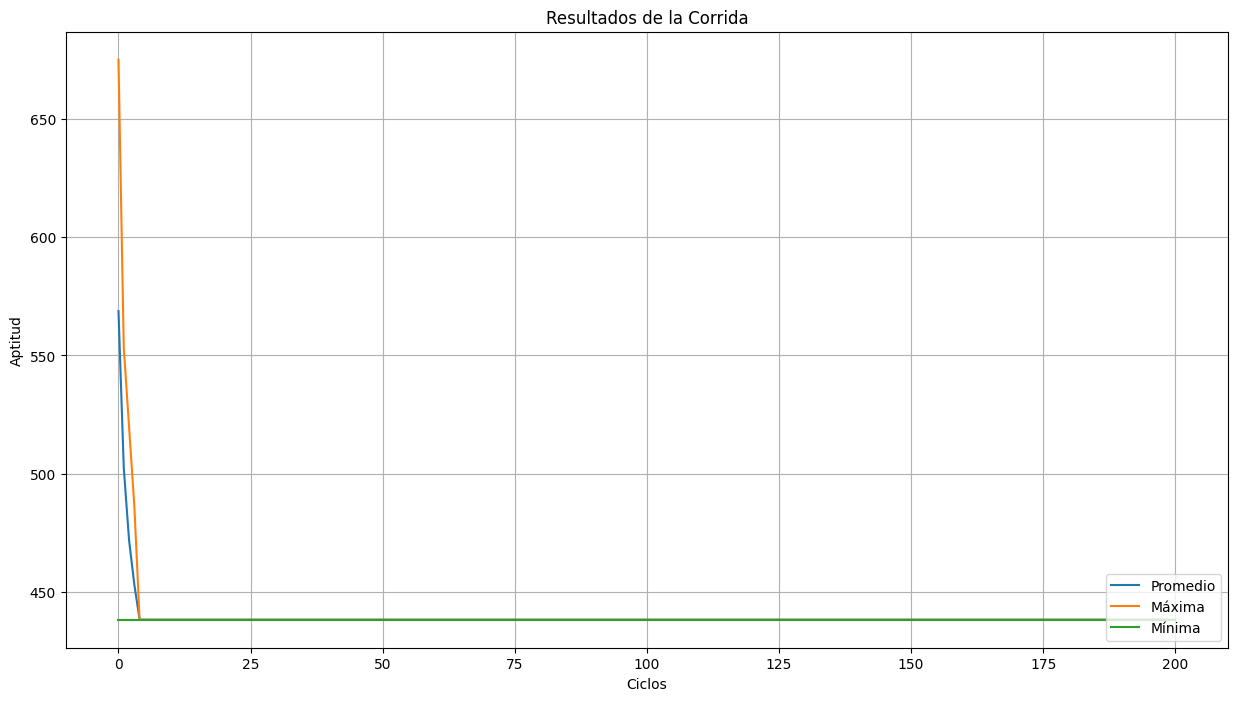

In [9]:
#@title Mostrar Gráfico de Estadísticas
alg.graficarEstadisticas()

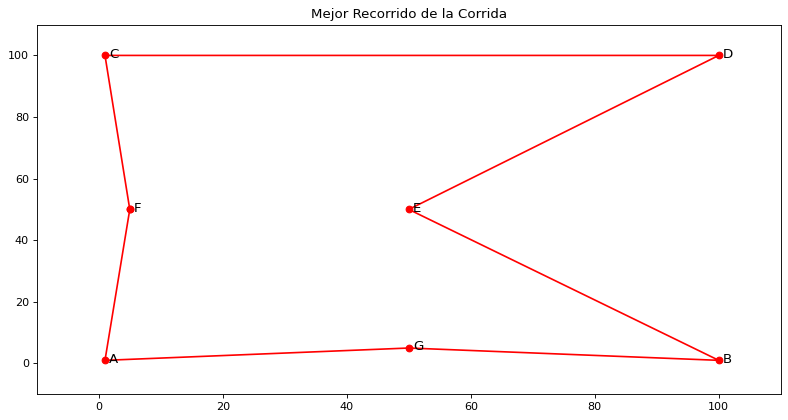

== Mejor Recorrido de la Corrida: [ F - C - D - E - B - G - A ] { 438.363 } en ciclo 0 == 



In [10]:
#@title Mostrar Mejor Recorrido de la Corrida


# Muesta el gráfico del Mejor Recorrido
fig, ax = mapa.graficar(mostrar=False)
# determina el recorrido
# Determina las coordenadas x, y de las posiciones en el mejor recorrido
X, Y = mapa.devPosicionesRecorrido( alg.mejorIndCorrida )
# muesta el recorrido
ax.plot(X, Y, 'o-r')
ax.set_title("Mejor Recorrido de la Corrida")
#plt.tight_layout()
plt.show()
print(msgMejor, "\n")
